In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('answers.csv')
questions = df.columns

### CelebA
#### Explainers

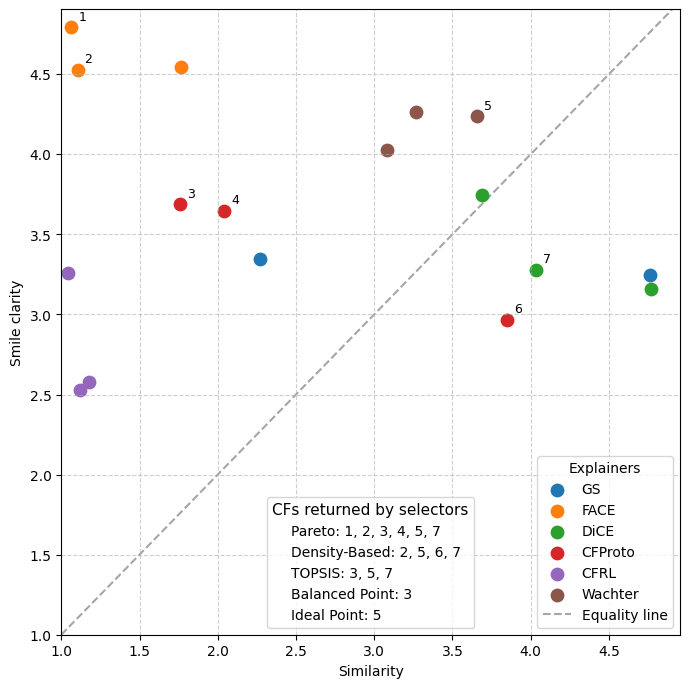

In [3]:
from matplotlib.lines import Line2D
explainers = {
    'GS': [1, 7],
    'FACE': [2, 8, 13],
    'DiCE': [3, 9, 14],
    'CFProto': [4, 10, 15],
    'CFRL': [5, 11, 16],
    'Wachter': [6, 12, 17] 
}
all_sim = []
all_dp = []


for i in range(1,18):
    sim_cols = [f'{i}. Jak bardzo kontrfakt jest podobny do oryginału?']
    dp_cols = [f'{i}. Czy twarz z kontrfaktu rzeczywiście się uśmiecha?']

    mean_sim = df[sim_cols].values.mean()
    mean_dp = df[dp_cols].values.mean()
    
    all_sim.append(mean_sim)
    all_dp.append(mean_dp)

plt.figure(figsize=(7, 7))

j = 0
order = [2, 1, 7, 3, 6, 4, 5]
for explainer, indices in explainers.items():
    xs = [all_sim[i - 1] for i in indices]
    ys = [all_dp[i - 1] for i in indices]

    plt.scatter(xs, ys, s=80, label=explainer)

    for i, x, y in zip(indices, xs, ys):
        if i in [2, 3, 6, 4, 10, 13, 15]:
            plt.annotate(
                str(order[j]),
                (x, y),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
            j+=1
    
plt.xlabel('Similarity')
plt.ylabel('Smile clarity')
plt.ylim(bottom=1)
plt.xlim(left=1)
plt.grid(True, linestyle='--', alpha=0.6)
# 1. Determine the limits of the current plot
limit_min = min(plt.xlim()[0], plt.ylim()[0])
limit_max = max(plt.xlim()[1], plt.ylim()[1])

# 2. Plot the identity line (y=x)
# 'k--' makes it a black dashed line, zorder=0 puts it behind the points
plt.plot([limit_min, limit_max], [limit_min, limit_max], 
         color='grey', linestyle='--', linewidth=1.5, alpha=0.7, 
         zorder=0, label='Equality line')

leg1 = plt.legend(title='Explainers')
plt.gca().add_artist(leg1) # This is crucial to keep leg1 when leg2 is added

# 4. Create the second legend (Selection Strategies)
# We use 'None' for color or a neutral grey since these are cross-categorical
strategies = {
    'Pareto': '1, 2, 3, 4, 5, 7',
    'Density-Based': '2, 5, 6, 7',
    'TOPSIS': '3, 5, 7',
    'Balanced Point': '3',
    'Ideal Point': '5'
}

# Create proxy artists for the strategies
strategy_handles = [
    Line2D([0], [0], color='none', label=f'{k}: {v}') 
    for k, v in strategies.items()
]

# Add the second legend
# Adjust bbox_to_anchor to position it where it doesn't overlap points
leg2 = plt.legend(
    handles=strategy_handles, 
    title='CFs returned by selectors',
    loc='lower center',
    fontsize=10,
    title_fontsize=11,
    handlelength=0, # Hide the line part of the proxy artist
    frameon=True
)
plt.tight_layout()
# plt.savefig('celebA_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


In [4]:
sim_scores = []
dp_scores = []
overall_scores_c = {}

for explainer, questions in explainers.items():
    sim_cols = [f'{i}. Jak bardzo kontrfakt jest podobny do oryginału?' for i in questions]
    dp_cols = [f'{i}. Czy twarz z kontrfaktu rzeczywiście się uśmiecha?' for i in questions]

    mean_sim = df[sim_cols].values.mean()
    mean_dp = df[dp_cols].values.mean()

    # print(f"{explainer} - Podobieństwo: średnia = {mean_sim:.2f}")
    # print(f"{explainer} - Uśmiech: średnia = {mean_dp:.2f}")
    # print(f"{explainer} - overall: średnia = {(mean_dp+mean_sim)/2:.2f}")

    sim_scores.append(mean_sim)
    dp_scores.append(mean_dp)
    overall_scores_c[explainer] = round((mean_dp+mean_sim)/2, 2)

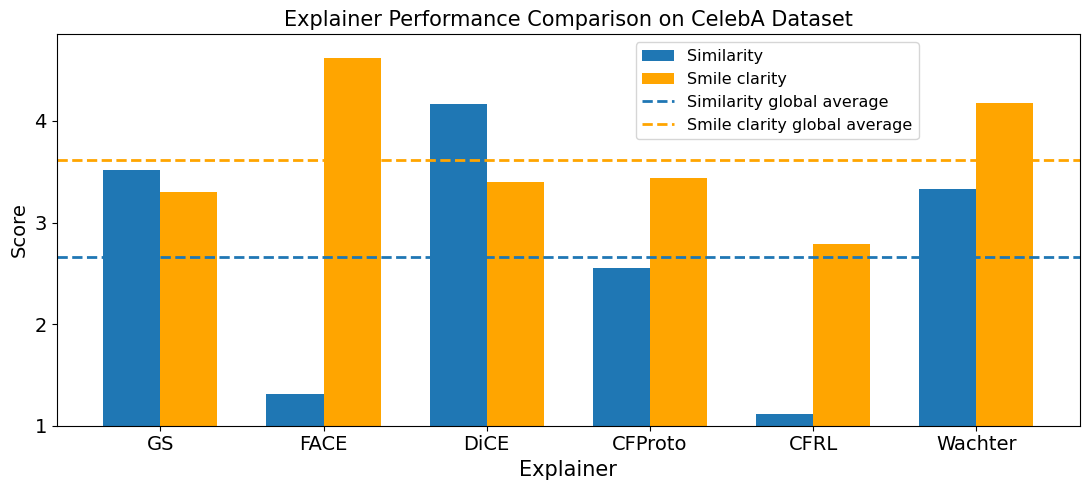

In [5]:
x = np.arange(len(explainers))
width = 0.35
sim_avg = np.mean(sim_scores)
dp_avg = np.mean(dp_scores)

plt.figure(figsize=(11, 5))

plt.bar(x - width/2, sim_scores, width, label='Similarity')
plt.bar(x + width/2, dp_scores, width, color = 'orange', label='Smile clarity')

plt.xticks(x, explainers.keys(), fontsize=14)
plt.yticks(ticks=[1, 2, 3, 4], fontsize=14)
plt.ylim(bottom=1)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Explainer', fontsize=15)
plt.title('Explainer Performance Comparison on CelebA Dataset', fontsize=15)
plt.axhline(
    y=sim_avg,
    linestyle='--',
    linewidth=2,
    label='Similarity global average'
)
plt.axhline(
    y=dp_avg,
    linestyle='--',
    linewidth=2,
    color='orange',
    label='Smile clarity global average'
)
plt.tight_layout()
handles, labels = plt.gca().get_legend_handles_labels()

desired_order = [
    'Similarity',
    'Smile clarity',
    'Similarity global average',
    'Smile clarity global average'
]

ordered_handles = [handles[labels.index(l)] for l in desired_order]
ordered_labels = desired_order
plt.legend(
    ordered_handles, 
    desired_order, 
    fontsize=11.5, 
    loc='upper right', 
    bbox_to_anchor=(0.85, 1.0)
)
# plt.savefig('celebA_explainers.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
sorted_scores = sorted(overall_scores_c.items(), key=lambda kv: -kv[1])
sorted_scores

[('DiCE', np.float64(3.78)),
 ('Wachter', np.float64(3.75)),
 ('GS', np.float64(3.41)),
 ('CFProto', np.float64(2.99)),
 ('FACE', np.float64(2.97)),
 ('CFRL', np.float64(1.95))]

#### Selectors

In [7]:
sim_scores = []
dp_scores = []
overall_scores = {}

all = [i for i in range(1,18)]
sim_cols = [f'{i}. Jak bardzo kontrfakt jest podobny do oryginału?' for i in all]
dp_cols = [f'{i}. Czy twarz z kontrfaktu rzeczywiście się uśmiecha?' for i in all]

mean_sim = df[sim_cols].values.mean()
mean_dp = df[dp_cols].values.mean()

sim_scores.append(mean_sim)
dp_scores.append(mean_dp)
overall_scores['All'] = round((mean_dp+mean_sim)/2, 2)

# median_sim = np.median(df[sim_cols].values)
# median_dp = np.median(df[dp_cols].values)

# print(f"ALL - Podobieństwo: średnia = {mean_sim:.2f}")
# print(f"ALL - Uśmiech: średnia = {mean_dp:.2f}")
# print(f"ALL - overall: średnia = {(mean_dp+mean_sim)/2:.2f}")

In [8]:
pareto = [2, 3, 4, 13, 15, 6]

sim_cols = [f'{i}. Jak bardzo kontrfakt jest podobny do oryginału?' for i in pareto]
dp_cols = [f'{i}. Czy twarz z kontrfaktu rzeczywiście się uśmiecha?' for i in pareto]

mean_sim = df[sim_cols].values.mean()
mean_dp = df[dp_cols].values.mean()

sim_scores.append(mean_sim)
dp_scores.append(mean_dp)
overall_scores['Pareto'] = round((mean_dp+mean_sim)/2, 2)

# median_sim = np.median(df[sim_cols].values)
# median_dp = np.median(df[dp_cols].values)

# print(f"pareto - Podobieństwo: średnia = {mean_sim:.2f}")
# print(f"pareto - Uśmiech: średnia = {mean_dp:.2f}")
# print(f"pareto - overall: średnia = {(mean_dp+mean_sim)/2:.2f}")


In [9]:
balancedPoint = 4
sim_cols = [f'{balancedPoint}. Jak bardzo kontrfakt jest podobny do oryginału?']
dp_cols = [f'{balancedPoint}. Czy twarz z kontrfaktu rzeczywiście się uśmiecha?']

mean_sim = df[sim_cols].values.mean()
mean_dp = df[dp_cols].values.mean()

sim_scores.append(mean_sim)
dp_scores.append(mean_dp)
overall_scores['BalancedPoint'] = round((mean_dp+mean_sim)/2, 2)

# median_sim = np.median(df[sim_cols].values)
# median_dp = np.median(df[dp_cols].values)

# print(f"balancedPoint - Podobieństwo: średnia = {mean_sim:.2f}")
# print(f"balancedPoint - Uśmiech: średnia = {mean_dp:.2f}")
# print(f"balancedPoint - overall: średnia = {(mean_dp+mean_sim)/2:.2f}")

In [10]:
densityBased = [2, 3, 6, 10]
sim_cols = [f'{i}. Jak bardzo kontrfakt jest podobny do oryginału?' for i in densityBased]
dp_cols = [f'{i}. Czy twarz z kontrfaktu rzeczywiście się uśmiecha?' for i in densityBased]

mean_sim = df[sim_cols].values.mean()
mean_dp = df[dp_cols].values.mean()

sim_scores.append(mean_sim)
dp_scores.append(mean_dp)
overall_scores['DensityBased'] = round((mean_dp+mean_sim)/2, 2)

# median_sim = np.median(df[sim_cols].values)
# median_dp = np.median(df[dp_cols].values)

# print(f"densityBased - Podobieństwo: średnia = {mean_sim:.2f}")
# print(f"densityBased - Uśmiech: średnia = {mean_dp:.2f}")
# print(f"densityBased - overall: średnia = {(mean_dp+mean_sim)/2:.2f}")


In [11]:
idealPoint = 6
sim_cols = [f'{idealPoint}. Jak bardzo kontrfakt jest podobny do oryginału?']
dp_cols = [f'{idealPoint}. Czy twarz z kontrfaktu rzeczywiście się uśmiecha?']

mean_sim = df[sim_cols].values.mean()
mean_dp = df[dp_cols].values.mean()

sim_scores.append(mean_sim)
dp_scores.append(mean_dp)
overall_scores['IdealPoint'] = round((mean_dp+mean_sim)/2, 2)

# median_sim = np.median(df[sim_cols].values)
# median_dp = np.median(df[dp_cols].values)

# print(f"idealPoint - Podobieństwo: średnia = {mean_sim:.2f}")
# print(f"idealPoint - Uśmiech: średnia = {mean_dp:.2f}")
# print(f"idealPoint - overall: średnia = {(mean_dp+mean_sim)/2:.2f}")

In [12]:
topsis = [3, 4, 6]
sim_cols = [f'{i}. Jak bardzo kontrfakt jest podobny do oryginału?' for i in topsis]
dp_cols = [f'{i}. Czy twarz z kontrfaktu rzeczywiście się uśmiecha?' for i in topsis]

mean_sim = df[sim_cols].values.mean()
mean_dp = df[dp_cols].values.mean()

sim_scores.append(mean_sim)
dp_scores.append(mean_dp)
overall_scores['Topsis'] = round((mean_dp+mean_sim)/2, 2)

# median_sim = np.median(df[sim_cols].values)
# median_dp = np.median(df[dp_cols].values)

# print(f"topsis - Podobieństwo: średnia = {mean_sim:.2f}")
# print(f"topsis - Uśmiech: średnia = {mean_dp:.2f}")
# print(f"topsis - overall: średnia = {(mean_dp+mean_sim)/2:.2f}")

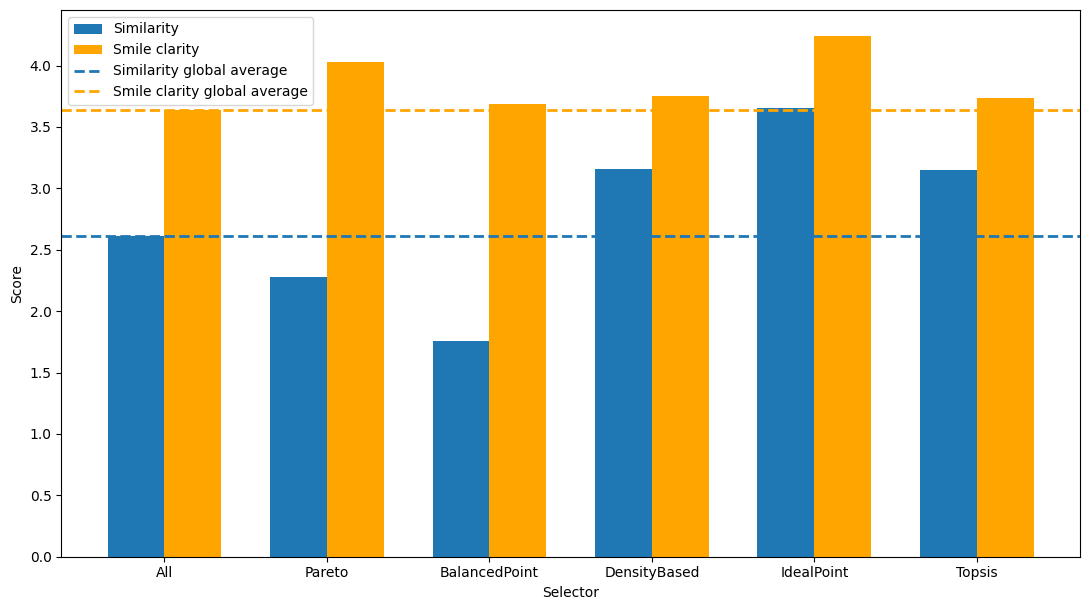

In [13]:
selectors = ['All', 'Pareto', 'BalancedPoint', 'DensityBased', 'IdealPoint', 'Topsis']
x = np.arange(len(selectors))
width = 0.35
sim_avg = sim_scores[0]
dp_avg = dp_scores[0]

plt.figure(figsize=(11, 6.2))
plt.bar(x - width/2, sim_scores, width, label='Similarity')
plt.bar(x + width/2, dp_scores, width, color = 'orange', label='Smile clarity')

plt.xticks(x, selectors)
plt.ylabel('Score')
plt.xlabel('Selector')
plt.axhline(
    y=sim_avg,
    linestyle='--',
    linewidth=2,
    label='Similarity global average'
)
plt.axhline(
    y=dp_avg,
    linestyle='--',
    linewidth=2,
    color='orange',
    label='Smile clarity global average'
)
plt.tight_layout()
handles, labels = plt.gca().get_legend_handles_labels()

desired_order = [
    'Similarity',
    'Smile clarity',
    'Similarity global average',
    'Smile clarity global average'
]

ordered_handles = [handles[labels.index(l)] for l in desired_order]
ordered_labels = desired_order
plt.legend(ordered_handles, ordered_labels)
plt.show()

In [14]:
sorted_scores = sorted(overall_scores.items(), key=lambda kv: -kv[1])
sorted_scores

[('IdealPoint', np.float64(3.95)),
 ('DensityBased', np.float64(3.46)),
 ('Topsis', np.float64(3.44)),
 ('Pareto', np.float64(3.15)),
 ('All', np.float64(3.13)),
 ('BalancedPoint', np.float64(2.72))]

### MNIST

In [15]:
questions = df.columns
questions[54:79:2]

Index(['18. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 1?',
       '19. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 1?',
       '20. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 1?',
       '21. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 1?',
       '22. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 1?',
       '23. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 1?',
       '24. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 8?',
       '25. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 5?',
       '26. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 1?',
       '27. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 1?',
       '28. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 1?',
       '29. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 3?',
       '30. Czy cyfra z kontrfaktu rzeczywiście wygląda jak 4?'],
      dtype='object')

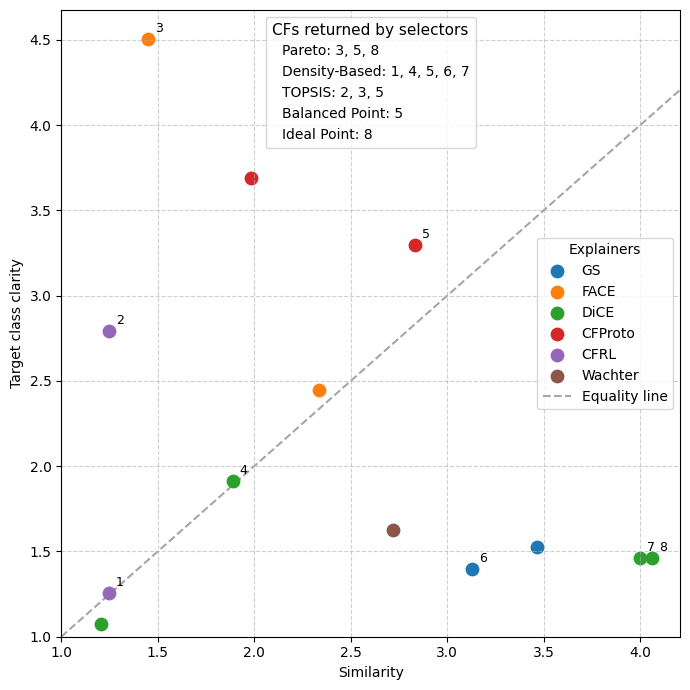

In [16]:
explainers = {
    'GS': [19, 25],
    'FACE': [20, 26],
    'DiCE': [21, 22, 27, 28],
    'CFProto': [23, 29],
    'CFRL': [24, 30],
    'Wachter': [18]
}
all_sim = []
all_dp = []


for i in range(53, 79, 2):
    sim_cols = questions[i]
    dp_cols = questions[i+1]
    mean_sim = df[sim_cols].values.mean()
    mean_dp = df[dp_cols].values.mean()

    all_sim.append(mean_sim)
    all_dp.append(mean_dp)

plt.figure(figsize=(7, 7))

j = 0
order = [6, 3, 7, 8, 4, 5, 1, 2]
for explainer, indices in explainers.items():
    xs = [all_sim[i - 18] for i in indices]
    ys = [all_dp[i - 18] for i in indices]

    plt.scatter(xs, ys, s=80, label=explainer)

    for i, x, y in zip(indices, xs, ys):
        if i in [20, 21, 22, 23, 24, 25, 27, 30]:
            plt.annotate(
                str(order[j]),
                (x, y),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
            j+=1

plt.xlabel('Similarity')
plt.ylabel('Target class clarity')
plt.ylim(bottom=1)
plt.xlim(left=1)
plt.grid(True, linestyle='--', alpha=0.6)
# 1. Determine the limits of the current plot
limit_min = min(plt.xlim()[0], plt.ylim()[0])
limit_max = max(plt.xlim()[1], plt.ylim()[1])

# 2. Plot the identity line (y=x)
# 'k--' makes it a black dashed line, zorder=0 puts it behind the points
plt.plot([limit_min, limit_max], [limit_min, limit_max], 
         color='grey', linestyle='--', linewidth=1.5, alpha=0.7, 
         zorder=0, label='Equality line')

leg1 = plt.legend(title='Explainers')
plt.gca().add_artist(leg1) # This is crucial to keep leg1 when leg2 is added

# 4. Create the second legend (Selection Strategies)
# We use 'None' for color or a neutral grey since these are cross-categorical
strategies = {
    'Pareto': '3, 5, 8',
    'Density-Based': '1, 4, 5, 6, 7',
    'TOPSIS': '2, 3, 5',
    'Balanced Point': '5',
    'Ideal Point': '8'
}

# Create proxy artists for the strategies
strategy_handles = [
    Line2D([0], [0], color='none', label=f'{k}: {v}') 
    for k, v in strategies.items()
]

# Add the second legend
# Adjust bbox_to_anchor to position it where it doesn't overlap points
leg2 = plt.legend(
    handles=strategy_handles, 
    title='CFs returned by selectors',
    loc='upper center',
    fontsize=10,
    title_fontsize=11,
    handlelength=0, # Hide the line part of the proxy artist
    frameon=True
)

plt.tight_layout()
# plt.savefig('MNIST_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


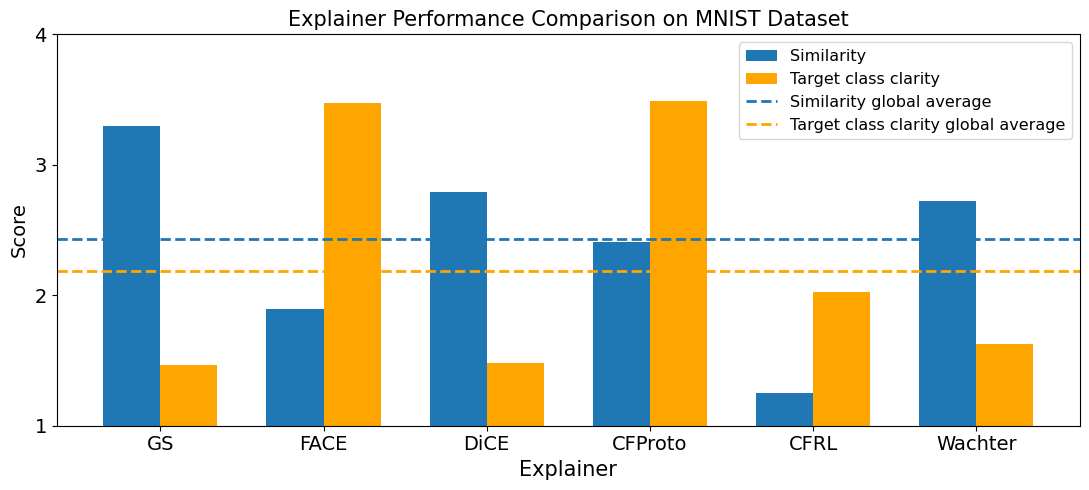

In [17]:
# 1. Calculate averages per explainer
sim_scores = []
dp_scores = []
explainer_names = list(explainers.keys())
overall_scores = {}

for name in explainer_names:
    indices = explainers[name]
    # Map index (18-30) to list position (0-12) by subtracting 18
    avg_sim = np.mean([all_sim[i - 18] for i in indices])
    avg_dp = np.mean([all_dp[i - 18] for i in indices])
    
    sim_scores.append(avg_sim)
    dp_scores.append(avg_dp)
    overall_scores[name] = round((avg_sim+avg_dp)/2, 2)

# 2. Calculate global averages for the horizontal lines
sim_avg_global = np.mean(all_sim)
dp_avg_global = np.mean(all_dp)

# 3. Plotting
x = np.arange(len(explainer_names))
width = 0.35

plt.figure(figsize=(11, 5))

# Plot bars
plt.bar(x - width/2, sim_scores, width, label='Similarity')
plt.bar(x + width/2, dp_scores, width, label='Target class clarity', color='orange')

# Add global average lines
plt.axhline(y=sim_avg_global, linestyle='--', linewidth=2, label='Similarity global average')
plt.axhline(y=dp_avg_global, linestyle='--', linewidth=2, color='orange', label='Target class clarity global average')

# Formatting
plt.xticks(x, explainers.keys(), fontsize=14)
plt.yticks(ticks=[1, 2, 3, 4], fontsize=14)
plt.ylim(bottom=1)
plt.ylabel('Score', fontsize=14)
plt.xlabel('Explainer', fontsize=15)
plt.title('Explainer Performance Comparison on MNIST Dataset', fontsize=15)
# plt.grid(axis='y', linestyle='--', alpha=0.4)

# Reordering legend
handles, labels = plt.gca().get_legend_handles_labels()
desired_order = [
    'Similarity',
    'Target class clarity',
    'Similarity global average',
    'Target class clarity global average'
]
ordered_handles = [handles[labels.index(l)] for l in desired_order]
plt.legend(
    ordered_handles, 
    desired_order, 
    fontsize=11.5, 
    loc='upper right', 
)

plt.tight_layout()
# plt.savefig('MNIST_explainers.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
sorted_scores = sorted(overall_scores.items(), key=lambda kv: -kv[1])
sorted_scores

[('CFProto', np.float64(2.95)),
 ('FACE', np.float64(2.68)),
 ('GS', np.float64(2.38)),
 ('Wachter', np.float64(2.17)),
 ('DiCE', np.float64(2.13)),
 ('CFRL', np.float64(1.64))]

In [19]:
images_overall = {}
for ex, val in overall_scores_c.items():
    images_overall[ex] = round((overall_scores[ex]+overall_scores_c[ex])/2, 2)

sorted_im_overall = sorted(images_overall.items(), key=lambda kv: -kv[1])
sorted_im_overall

[('CFProto', np.float64(2.97)),
 ('DiCE', np.float64(2.96)),
 ('Wachter', np.float64(2.96)),
 ('GS', np.float64(2.9)),
 ('FACE', np.float64(2.82)),
 ('CFRL', np.float64(1.8))]

### Titanic

In [20]:
df = pd.read_csv('answers.csv')
questions = df.columns
df[questions[51]].iloc[0]

'Płeć: mężczyzna->kobieta, Wiek: 56->43.46, Opłata: 35.50->61.39;, Klasa: 1->3, Płeć: mężczyzna->kobieta, Wiek: 56->28.83, Opłata: 35.50->0, Rodzeństwo/Małżonkowie: 0->0.65;, Wiek: 56->17.50, Płeć: mężczyzna->kobieta;, Rodzeństwo/Małżonkowie: 0->5, Płeć: mężczyzna->kobieta;, Rodzeństwo/Małżonkowie: 0->5, Opłata: 35.50->250.89;, Rodzeństwo/Małżonkowie: 0->3, Klasa: 1->3;, Rodzeństwo/Małżonkowie: 0->1.11;, Opłata: 35.50->40.75, Rodzeństwo/Małżonkowie: 0->0.10, Wiek: 56->57.07;, Wiek: 56->64, Opłata: 35.50->27.72;'

In [21]:
def rank(q):
    target_col = questions[q]

    cfs = df[target_col].iloc[0].split(';, ')
    cfs[-1] = cfs[-1][:-1]

    # for cf in cfs:
    #     print(cf)

    stats = {cf: {rank: 0 for rank in range(1, len(cfs) + 1)} for cf in cfs}

    for ranking in df[target_col]:
        for index, cfs in enumerate(ranking.split(';, ')):
            if index == 8:
                cfs = cfs[:-1]
            rank = index + 1
            stats[cfs][rank] += 1

    scores = {}

    for cf in stats:
        scores[cf] = round((sum(stats[cf][i+1]*((9-i)**2) for i in range(9))/10), 0)    

    sorted_scores = sorted(scores.items(), key=lambda kv: -kv[1])
    print(sorted_scores)

In [22]:
r51 = rank(51)

[('Wiek: 56->17.50, Płeć: mężczyzna->kobieta', 538.0), ('Płeć: mężczyzna->kobieta, Wiek: 56->43.46, Opłata: 35.50->61.39', 520.0), ('Klasa: 1->3, Płeć: mężczyzna->kobieta, Wiek: 56->28.83, Opłata: 35.50->0, Rodzeństwo/Małżonkowie: 0->0.65', 460.0), ('Rodzeństwo/Małżonkowie: 0->5, Płeć: mężczyzna->kobieta', 428.0), ('Rodzeństwo/Małżonkowie: 0->5, Opłata: 35.50->250.89', 405.0), ('Wiek: 56->64, Opłata: 35.50->27.72', 346.0), ('Rodzeństwo/Małżonkowie: 0->3, Klasa: 1->3', 295.0), ('Rodzeństwo/Małżonkowie: 0->1.11', 295.0), ('Opłata: 35.50->40.75, Rodzeństwo/Małżonkowie: 0->0.10, Wiek: 56->57.07', 274.0)]


In [23]:
r52 = rank(52)

[('Klasa: 2->1, Rodzice/Dzieci: 1->1.26, Rodzeństwo/Małżonkowie: 2->2.21, Wiek: 23->25.60, Opłata: 11.50->19.30', 474.0), ('Wiek: 23->3.70', 449.0), ('Rodzice/Dzieci: 1->5, Płeć: mężczyzna->kobieta', 424.0), ('Klasa: 2->1, Rodzice/Dzieci: 1->1.80, Rodzeństwo/Małżonkowie: 2->3.11', 416.0), ('Wiek: 23->8, Rodzeństwo/Małżonkowie: 2->1, Opłata: 11.50->36.75', 383.0), ('Wiek: 23->8.50', 382.0), ('Klasa: 2->3, Płeć: mężczyzna->kobieta, Rodzice/Dzieci: 1->0, Rodzeństwo/Małżonkowie: 2->0.85, Wiek: 23->30.54, Opłata: 11.50->0', 358.0), ('Wiek: 23->17.43', 353.0), ('Rodzeństwo/Małżonkowie: 2->7, Klasa: 2->1', 322.0)]


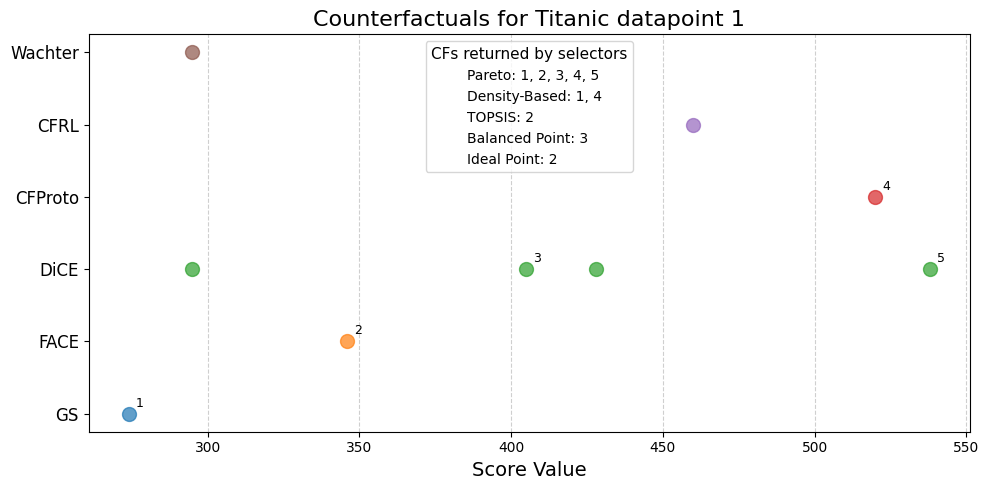

In [ ]:
# explainers_old = {
#     'GS': [510, 701],
#     'FACE': [562, 631],
#     'DiCE': [[528, 634, 675, 756], [607, 660, 551, 653]], 
#     'CFProto': [745, 588], 
#     'CFRL': [693, 588],
#     'Wachter': [522, 646],
# }

explainers = {
    'GS': [274, 474],
    'FACE': [346, 383],
    'DiCE': [[538, 428, 405, 295], [449, 424, 382, 322]], 
    'CFProto': [520, 353], 
    'CFRL': [460, 358],
    'Wachter': [295, 416]
}

plt.figure(figsize=(10, 5))

for i, (name, values) in enumerate(explainers.items()):
    # Get the first component
    first_comp = values[0]
    
    # If it's a list (like DiCE), plot all points in that list
    if isinstance(first_comp, list):
        plt.scatter(first_comp, [name] * len(first_comp), s=100, alpha=0.7)
        plt.annotate(
                str(3),
                (first_comp[2], name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
        plt.annotate(
                str(5),
                (first_comp[0], name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    else:
        plt.scatter([first_comp], [name], s=100, alpha=0.7)
    
    if name=='GS':
        plt.annotate(
                str(1),
                (first_comp, name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    if name=='FACE':
        plt.annotate(
                str(2),
                (first_comp, name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    if name=='CFProto':
        plt.annotate(
                str(4),
                (first_comp, name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
        
strategies = {
    'Pareto': '1, 2, 3, 4, 5',
    'Density-Based': '1, 4',
    'TOPSIS': '2',
    'Balanced Point': '3',
    'Ideal Point': '2'
}

# Create proxy artists for the strategies
strategy_handles = [
    Line2D([0], [0], color='none', label=f'{k}: {v}') 
    for k, v in strategies.items()
]

# Add the second legend
# Adjust bbox_to_anchor to position it where it doesn't overlap points
leg2 = plt.legend(
    handles=strategy_handles, 
    title='CFs returned by selectors',
    loc='upper center',
    fontsize=10,
    title_fontsize=11,
    handlelength=0, # Hide the line part of the proxy artist
    frameon=True
)
plt.xlabel('Score Value', fontsize=14)
plt.title('Counterfactuals for Titanic datapoint 1', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.yticks(fontsize=12)
plt.tight_layout()
# plt.savefig('titanic_cf1.png', dpi=300, bbox_inches='tight')
plt.show()

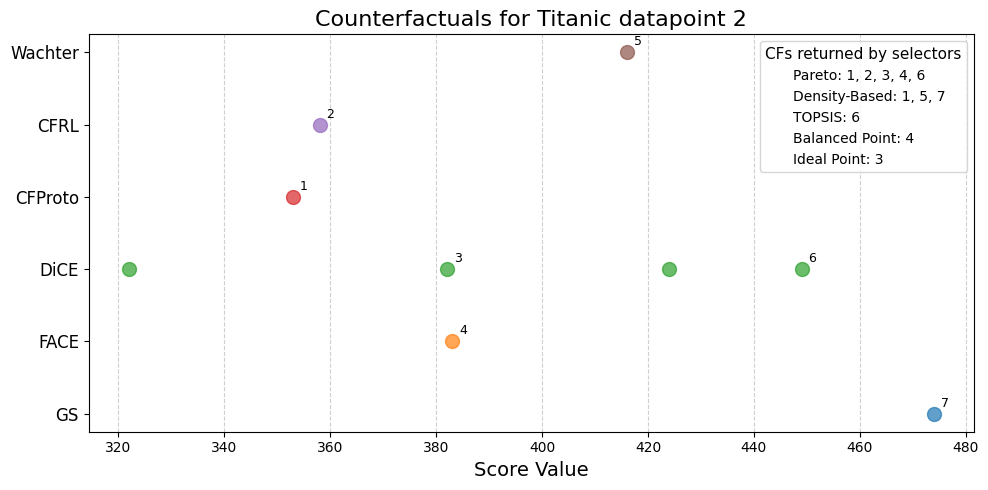

In [ ]:
plt.figure(figsize=(10, 5))

for i, (name, values) in enumerate(explainers.items()):
    # Get the first component
    sec_comp = values[1]
    
    # If it's a list (like DiCE), plot all points in that list
    if isinstance(sec_comp, list):
        plt.scatter(sec_comp, [name] * len(sec_comp), s=100, alpha=0.7)
        plt.annotate(
                str(3),
                (sec_comp[2], name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
        plt.annotate(
                str(6),
                (sec_comp[0], name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    else:
        plt.scatter([sec_comp], [name], s=100, alpha=0.7)
    
    if name=='CFProto':
        plt.annotate(
                str(1),
                (sec_comp, name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    if name=='CFRL':
        plt.annotate(
                str(2),
                (sec_comp, name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    if name=='FACE':
        plt.annotate(
                str(4),
                (sec_comp, name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    if name=='Wachter':
        plt.annotate(
                str(5),
                (sec_comp, name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    if name=='GS':
        plt.annotate(
                str(7),
                (sec_comp, name),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
strategies = {
    'Pareto': '1, 2, 3, 4, 6',
    'Density-Based': '1, 5, 7',
    'TOPSIS': '6',
    'Balanced Point': '4',
    'Ideal Point': '3'
}

# Create proxy artists for the strategies
strategy_handles = [
    Line2D([0], [0], color='none', label=f'{k}: {v}') 
    for k, v in strategies.items()
]

# Add the second legend
# Adjust bbox_to_anchor to position it where it doesn't overlap points
leg2 = plt.legend(
    handles=strategy_handles, 
    title='CFs returned by selectors',
    loc='upper right',
    fontsize=10,
    title_fontsize=11,
    handlelength=0, # Hide the line part of the proxy artist
    frameon=True
)
plt.xlabel('Score Value', fontsize=14)
plt.title('Counterfactuals for Titanic datapoint 2', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.yticks(fontsize=12)
plt.tight_layout()
# plt.savefig('titanic_cf2.png', dpi=300, bbox_inches='tight')
plt.show()